In [5]:
import pandas as pd
df_clean = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/global_temp_clean.csv")

In [9]:
# IQR method
df_clean = df_clean[["Date Cleaned", "Temperature_Anomaly"]].set_index("Date Cleaned")

<Axes: xlabel='Date Cleaned'>

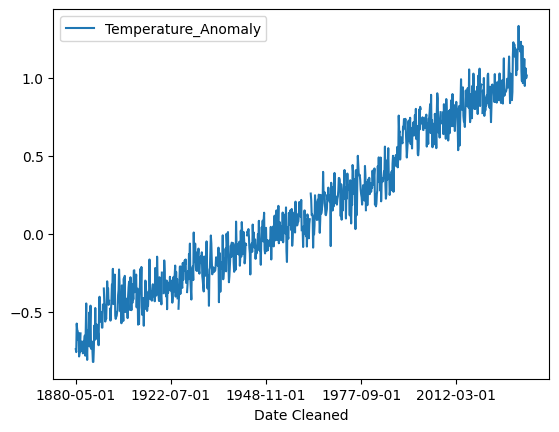

In [11]:
df_clean.plot()

<Axes: xlabel='Date Cleaned'>

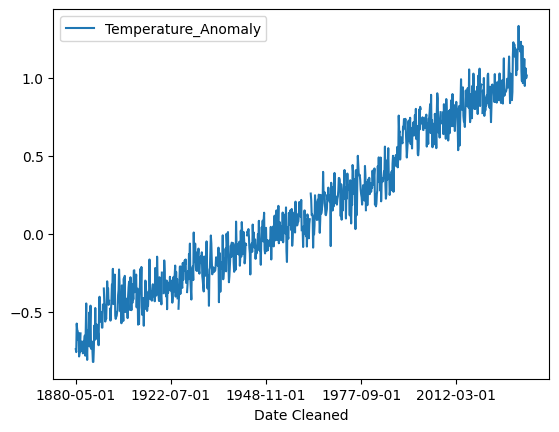

In [12]:
# IQR Method
Q1 = df_clean.quantile(0.25)
Q3 = df_clean.quantile(0.75)
IQR = Q3 - Q1
greater_than_q1 = df_clean > (Q1 - 1.5 * IQR)
smaller_than_q3 = df_clean < (Q3 + 1.5 * IQR)
df_clean[greater_than_q1 & smaller_than_q3].plot()

In [21]:
print("Q1", Q1.values)
print("Q3", Q3.values)
print("IQR", IQR.values)

Q1 [-0.242]
Q3 [0.646]
IQR [0.888]


In [25]:
df_clean[df_clean > Q3 + 1.5 * IQR].dropna()

,Temperature_Anomaly
Date Cleaned,


In [23]:
df_clean[df_clean < Q1 - 1.5 * IQR].dropna()

,Temperature_Anomaly
Date Cleaned,


In [29]:
df_clean.index = pd.to_datetime(df_clean.index)

In [33]:
# Reindex the series to a complete monthly grid from January 1880 to December 2025.
df_clean_full = df_clean.reindex(pd.date_range("1880-01-01", "2025-12-01", freq="MS"))

count_impunted = df_clean_full.isna().sum()
df_clean_full = df_clean_full.interpolate("linear", limit_direction="both")

In [39]:
mu_20 = df_clean_full[:"2000"].mean()
mu = df_clean_full.mean()
sigma = df_clean_full.std()
z_score = (df_clean_full - mu) / sigma

In [62]:
df_clean_full[df_clean_full.index.year == 1880]

,Temperature_Anomaly
1880-01-01,-0.739000
1880-02-01,-0.739000
1880-03-01,-0.739000
1880-04-01,-0.739000
1880-05-01,-0.739000
1880-06-01,-0.739237
1880-07-01,-0.739475
1880-08-01,-0.739712
1880-09-01,-0.739950
1880-10-01,-0.740187


In [59]:
df_clean_full['1880':'1880']

,Temperature_Anomaly
1880-01-01,-0.739000
1880-02-01,-0.739000
1880-03-01,-0.739000
1880-04-01,-0.739000
1880-05-01,-0.739000
1880-06-01,-0.739237
1880-07-01,-0.739475
1880-08-01,-0.739712
1880-09-01,-0.739950
1880-10-01,-0.740187


In [67]:
from numpy import average
# yearly mean, yearly z-score
res_list = []
for year in range(1880, 2026):
  df_sub = df_clean_full[df_clean_full.index.year == year]
  mean_year = df_sub.mean().iloc[0]
  std_year = df_sub.std().iloc[0]
  z_score_year = ((df_sub - mean_year) / std_year).mean().iloc[0]
  res = {
      "year": year,
      "mean": mean_year,
      "std": std_year,
      "z_score": z_score_year
  }
  res_list.append(res)

df_res = pd.DataFrame(res_list)

In [72]:
df_res.sort_values("mean", ascending=False).head(5)

,year,mean,std,z_score
144,2024,1.163042,0.092972,-7.401487e-16
143,2023,1.153208,0.062051,-8.789266e-16
145,2025,1.016208,0.044227,-1.053122e-15
142,2022,0.956625,0.081512,-2.238950e-15
141,2021,0.940042,0.073695,1.665335e-15
